In [1]:
import torch

# Format versions to match PyG wheel URL scheme
torch_version = torch.__version__.split('+')[0]
cuda_version = "cu" + torch.version.cuda.replace(".", "")
whl_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html"

print(f"Installing PyG for PyTorch {torch_version} and {cuda_version}...")

# Install base PyG
!pip install -q torch_geometric


# Install accelerated sparse tensor extensions using the generated URL
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster -f {whl_url}

print("Installation complete. Restart your runtime.")

Installing PyG for PyTorch 2.11.0 and cu128...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 51.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 129.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 125.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 48.3 MB/s eta 0:00:00
Installation complete. Restart your runtime.


In [1]:

from google.colab import drive
drive.mount('/content/drive')

import sys
# Add the project to the Python path so modules can be imported
sys.path.append('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

import os
# Change the working directory to the project folder
os.chdir('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

!pip install -q pandas numpy scipy pyyaml matplotlib kaggle

Mounted at /content/drive


# 03 — Full Closed Loop (Identify -> Generate -> Feature -> Defend -> Scoring -> Reward -> Feedback -> Dashboard)

This is the main entry point for your demo. Runs N full rounds of the
Red-vs-Blue self-play loop and builds the two dashboard artifacts your
requirements doc says to lead with: the coverage matrix and the
detection-rate-over-rounds chart.

**Run 00 first** (distribution fitting). This notebook does NOT require 01/02
to have been run first - `FraudRedTeamLoop` runs Identify+Generate+Defend
itself, every round, from scratch.

In [2]:
!pip install -q pandas numpy scipy pyyaml faker networkx scikit-learn lightgbm matplotlib

!pip install -q google-genai
!pip install groq
!export GROQ_API_KEY="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"
import time
import os
from google.colab import userdata

# Map your custom secret name to the standard Gemini env variable
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
# Replace with your exact secret name if different# Set this up via the key icon in Colab's left sidebar -> Secrets -> add ANTHROPIC_API_KEY

# Optional: torch_geometric for real GNN training (see notebook 02 for install steps).
# Pipeline runs fine without it via the fallback path - install it once the rest works
# if you have time before the deadline.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 12.8 MB/s eta 0:00:00


In [11]:
import sys
sys.path.insert(0, ".")
import shutil, os

shutil.copy("data/coverage_matrix.csv", "data/coverage_matrix_backup_12.csv")
shutil.copy("data/dashboard_log.csv", "data/dashboard_log_backup_12.csv")
os.remove("data/coverage_matrix.csv")
os.remove("data/dashboard_log.csv")

# fresh instance, not the old `loop` object — avoids stale in-memory validator/coverage state
from src.reward.loop_orchestrator import FraudRedTeamLoop
loop = FraudRedTeamLoop(
    f3_taxonomy_path="config/f3_taxonomy.json",
    schema_path="config/upi_schema.json",
    distribution_params_path="config/distribution_params.yaml",
    null_config_path="config/null_injection_rates.yaml",
    coverage_matrix_path="data/coverage_matrix.csv",
    dashboard_log_path="data/dashboard_log.csv",
)

history = loop.run(
    n_rounds=6,
    n_new_scenarios=3,
    n_legit_accounts=500,
    fraud_txns_per_scenario_range=(10, 20),
    reuse_state_across_rounds=True,   # <- the actual change
)


ROUND 0

[1/7] Identify: proposing new scenarios...
  [attempt 1] ACCEPTED: Device Fingerprint Spoofing with Behavioral Consistency (network)
  [attempt 2] ACCEPTED: Fabricated KYC Document Burst (identity)
  [attempt 3] ACCEPTED: Layered Mule Transfer Chain (network)

[2/7] Generate: producing synthetic transactions...
[round 0] 4074 txns (31 fraud, 0.761%) -> saved to data/generated/round_00

[3-4/7] Feature pipeline + Defend: training GBM/GNN/Sequence/Ensemble...

[5/7] Scoring: computing per-scenario detection rates...
                                          scenario_name  n_txns  n_caught  detection_rate
Device Fingerprint Spoofing with Behavioral Consistency      10         7        0.700000
                          Fabricated KYC Document Burst      17        16        0.941176
                            Layered Mule Transfer Chain       4         4        1.000000

[6/7] Reward: computing blue_reward and red_reward...
  blue_reward: 0.8695 (recall_new=0.871, fpr=0.0015)
  

## Run the loop

**Hackathon-scale stopping condition, per the spec: 3-5 rounds is enough to
show a clear detection-rate climb on at least 2 previously-missed
techniques** - that's your "learning happened" proof point. Don't over-run
this; more rounds costs more LLM API calls and Colab time without changing
your demo story much.

In [6]:
N_ROUNDS = 4

history = loop.run(
    n_rounds=N_ROUNDS,
    n_new_scenarios=3,          # new scenarios proposed per round
    n_legit_accounts=500,       # legit traffic volume per round
    fraud_txns_per_scenario_range=(10, 20),
    reuse_state_across_rounds=False,  # True = cumulative velocity/graph/behavioral state
                                        # across rounds (more realistic, slower to debug -
                                        # start with False, flip to True once stable)
)

print("\n\n=== FULL LOOP DASHBOARD LOG ===")
print(history.to_string(index=False))


ROUND 0

[1/7] Identify: proposing new scenarios...
  [attempt 1] ACCEPTED: Fabricated KYC with Geolocation Oscillation (identity)
  [attempt 2] ACCEPTED: Credential Stuffing with Device Fingerprint Rotation (network)
  [attempt 3] ACCEPTED: Cross-Account Refund Chaining (identity)

[2/7] Generate: producing synthetic transactions...
[round 0] 4086 txns (43 fraud, 1.052%) -> saved to data/generated/round_00

[3-4/7] Feature pipeline + Defend: training GBM/GNN/Sequence/Ensemble...


/usr/local/lib/python3.13/dist-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data_dict[key] = torch.as_tensor(value)



[5/7] Scoring: computing per-scenario detection rates...
                                       scenario_name  n_txns  n_caught  detection_rate
Credential Stuffing with Device Fingerprint Rotation      17         8        0.470588
                       Cross-Account Refund Chaining      16        11        0.687500
         Fabricated KYC with Geolocation Oscillation      10         5        0.500000

[6/7] Reward: computing blue_reward and red_reward...
  blue_reward: 0.5497 (recall_new=0.558, fpr=0.0084)
  red_reward [Fabricated KYC with Geolocation Oscillation]: 0.7500 (detection_rate=0.500, novelty=0.500)
  red_reward [Credential Stuffing with Device Fingerprint Rotation]: 0.9739 (detection_rate=0.471, novelty=0.889)
  red_reward [Cross-Account Refund Chaining]: 0.5625 (detection_rate=0.688, novelty=0.500)

[7/7] Feedback: generating miss explanations for next round...
  - [Credential Stuffing with Device Fingerprint Rotation] device fingerprint was null (a real fraud signal for 

## Build the demo dashboard

These two panels (coverage matrix + detection-rate-over-rounds) are what
your requirements doc says to show FIRST, before any single accuracy
number.

Dashboard saved to data/final_dashboard.png


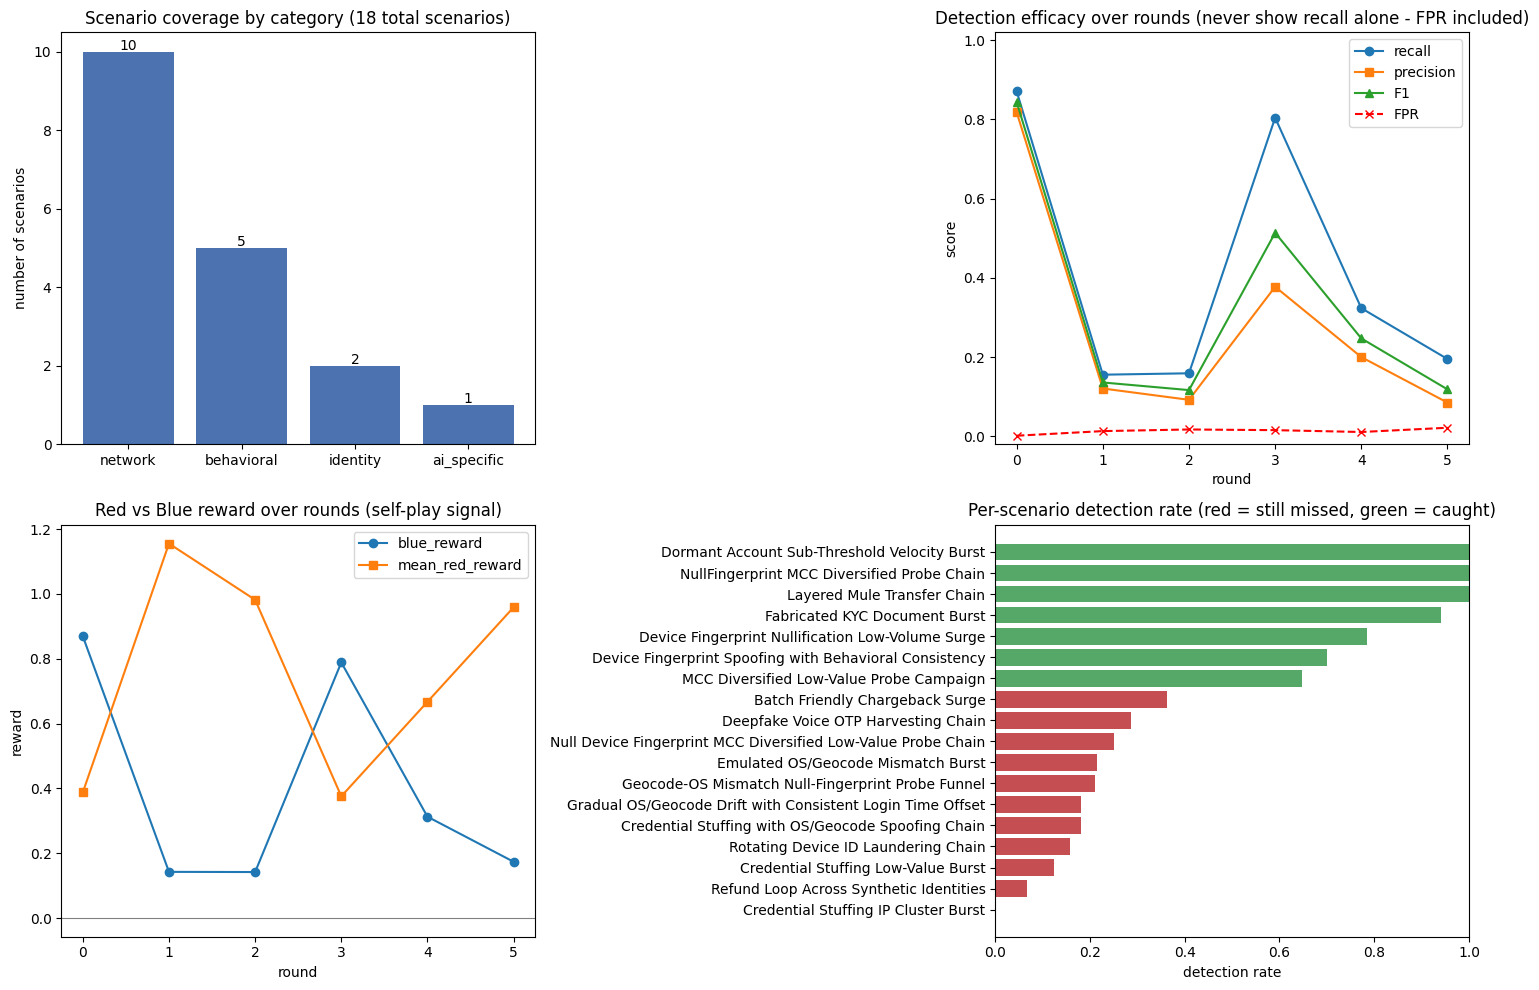


=== Coverage matrix table ===
                                                scenario_name         f3_tactic                    f3_technique manipulation_type                                           novelty_tag  detection_rate  round_added
      Device Fingerprint Spoofing with Behavioral Consistency           Channel     Device Fingerprint Spoofing           network  device_fingerprint_churn_with_behavioral_consistency        0.700000            0
                                Fabricated KYC Document Burst       Positioning     Synthetic Identity Creation          identity                         synthetic_kyc_doc_fabrication        0.941176            0
                                  Layered Mule Transfer Chain      Monetization           Mule Network Cash-Out           network                                layered_chain_velocity        1.000000            0
                          Deepfake Voice OTP Harvesting Chain Credential Access Phishing via AI-Generated Voice      

In [12]:
sys.path.insert(0, "dashboard")
from dashboard.build_dashboard import build_dashboard

build_dashboard(
    coverage_path="data/coverage_matrix.csv",
    dashboard_log_path="data/dashboard_log.csv",
    save_path="data/final_dashboard.png",
)

## Sanity-check the "learning happened" story

Confirm detection rate actually climbed on at least 2 previously-missed
scenario types across rounds - this is your headline demo claim.

In [8]:
import pandas as pd
cov = pd.read_csv("data/coverage_matrix.csv")
cov = cov[cov["detection_rate"].notna()].sort_values(["scenario_name", "round_added"])
print(cov[["scenario_name", "round_added", "detection_rate", "times_missed"]].to_string(index=False))

improved = cov[cov["times_missed"] >= 1]
print(f"\n{len(improved)} scenario(s) were missed at least once and are tracked for "
      f"round-over-round improvement - these are your before/after story.")

                                                  scenario_name  round_added  detection_rate  times_missed
AI-Driven Card Probe Network with Device Fingerprint Collisions            3        0.555556             0
                        Aggregated Sub-Threshold Velocity Surge            3        0.388889             1
             Coordinated Behavioral Drift via Bot Orchestration            2        0.222222             1
           Credential Stuffing with Device Fingerprint Rotation            0        0.470588             1
                                  Cross-Account Refund Chaining            0        0.687500             0
                              Delayed Chargeback Friendly Fraud            1        0.615385             0
            Device Fingerprint Nullification via Custom UPI SDK            3        0.692308             0
                    Fabricated KYC with Geolocation Oscillation            0        0.500000             0
                       Mule Network L

## Miss-explanation examples (Feedback engine output)

These plain-language explanations are what fed the Identify engine's
context each round - a good talking point for the "novelty" section of
your pitch (this is the part that closes the loop from "here's a metric"
to "here's a plain-language reason").

In [9]:
for exp in loop.miss_explanations[:10]:
    print("-", exp)

- [AI-Driven Card Probe Network with Device Fingerprint Collisions] transaction had moderate signal across subsystems but stayed under the ensemble's decision threshold - consider whether the threshold is tuned too conservatively for this scenario type
- [AI-Driven Card Probe Network with Device Fingerprint Collisions] transaction had moderate signal across subsystems but stayed under the ensemble's decision threshold - consider whether the threshold is tuned too conservatively for this scenario type
- [AI-Driven Card Probe Network with Device Fingerprint Collisions] this transaction's amount was statistically unremarkable for the account - the anomaly here is likely only visible at an aggregation level the current feature set doesn't fully capture yet
- [Aggregated Sub-Threshold Velocity Surge] this transaction's amount was statistically unremarkable for the account - the anomaly here is likely only visible at an aggregation level the current feature set doesn't fully capture yet
- [A

## Before you present: self-check against the requirements doc

- [ ] Coverage matrix shows 8-10 genuinely distinct scenarios (not 30 near-duplicates)
- [ ] Detection-rate-over-rounds chart shows improvement on 2+ previously-missed techniques
- [ ] Precision/Recall/F1/FPR all reported, never recall alone
- [ ] Per-scenario detection table shown, not just one blended number
- [ ] Fidelity: KS-test / histogram overlay from notebook 00/01 ready to show
- [ ] Novelty explicitly named in your pitch, not left for judges to infer
- [ ] Feasibility: latency/FPR-cost/privacy/integration-point addressed honestly
- [ ] Clear about what's prototype vs what would need productionizing

Dashboard saved to data/final_dashboard.png


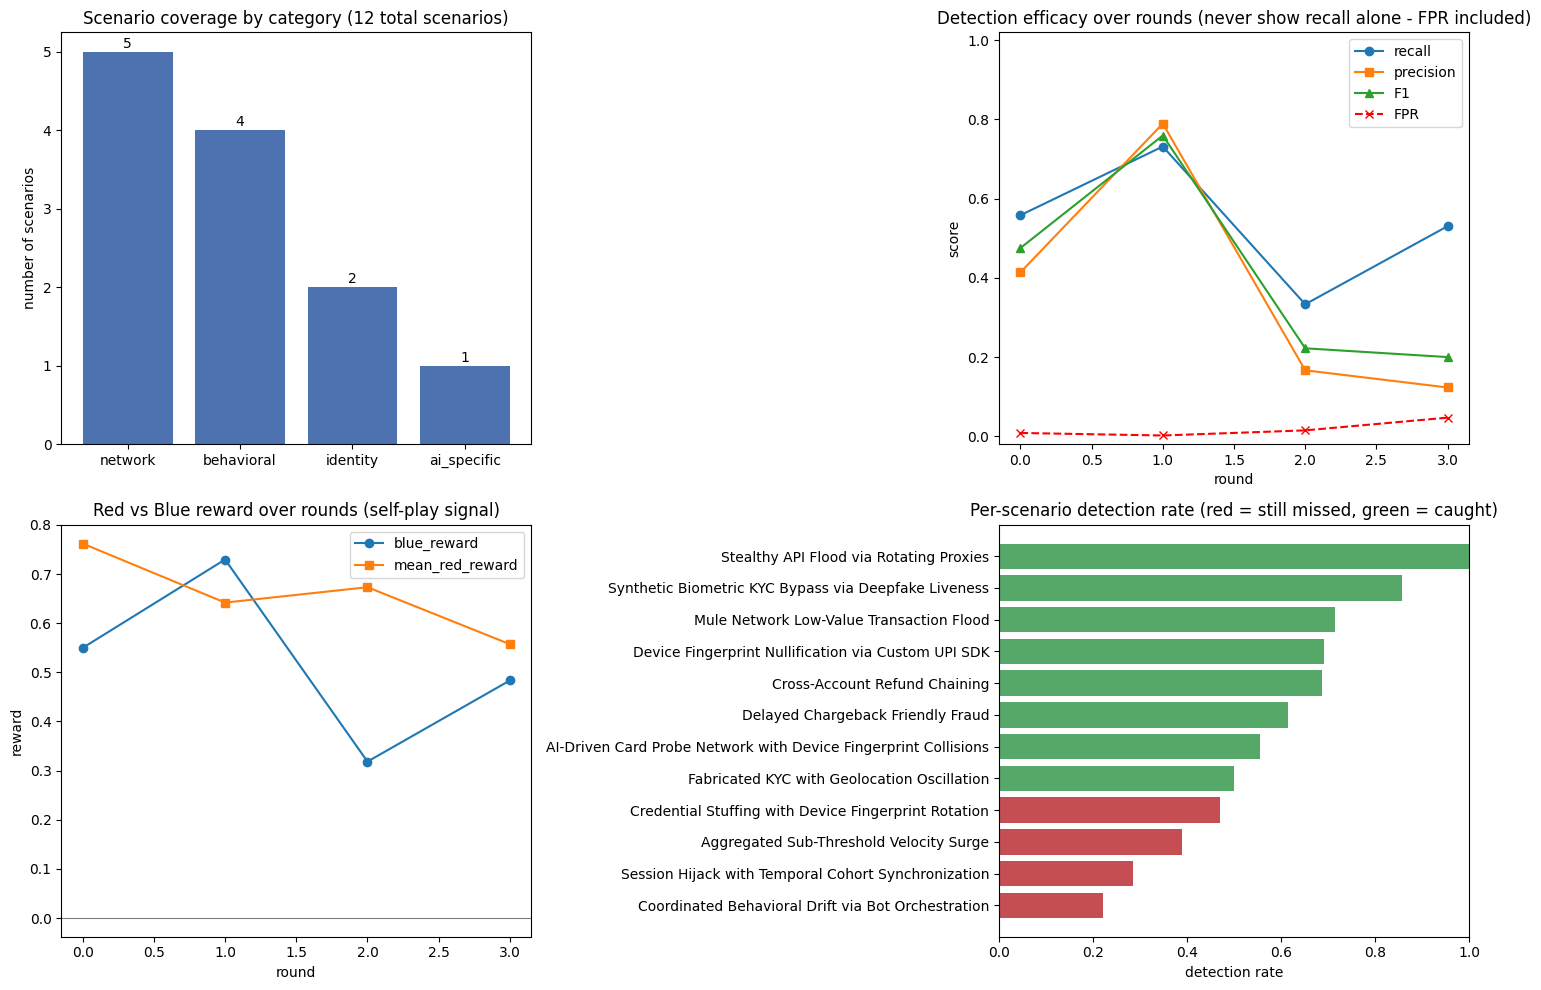


=== Coverage matrix table ===
                                                  scenario_name        f3_tactic                                                      f3_technique manipulation_type                                novelty_tag  detection_rate  round_added
                    Fabricated KYC with Geolocation Oscillation      Positioning                                       Synthetic Identity Creation          identity synthetic_identity_geolocation_oscillation        0.500000            0
           Credential Stuffing with Device Fingerprint Rotation Account Takeover                                               Credential stuffing           network   credential_stuffing_fingerprint_rotation        0.470588            0
                                  Cross-Account Refund Chaining     Monetization                                                Refund/Promo Abuse          identity              cross_account_refund_chaining        0.687500            0
           Synthetic 

In [10]:
import pandas as pd

log = pd.read_csv("data/dashboard_log.csv")
log_clean = log.tail(4).reset_index(drop=True)   # matches your reset coverage matrix run
log_clean.to_csv("data/dashboard_log.csv", index=False)  # overwrite so build_dashboard reads only this

from dashboard.build_dashboard import build_dashboard
build_dashboard(
    coverage_path="data/coverage_matrix.csv",
    dashboard_log_path="data/dashboard_log.csv",
    save_path="data/final_dashboard.png",
)

Dashboard saved to data/final_dashboard.png


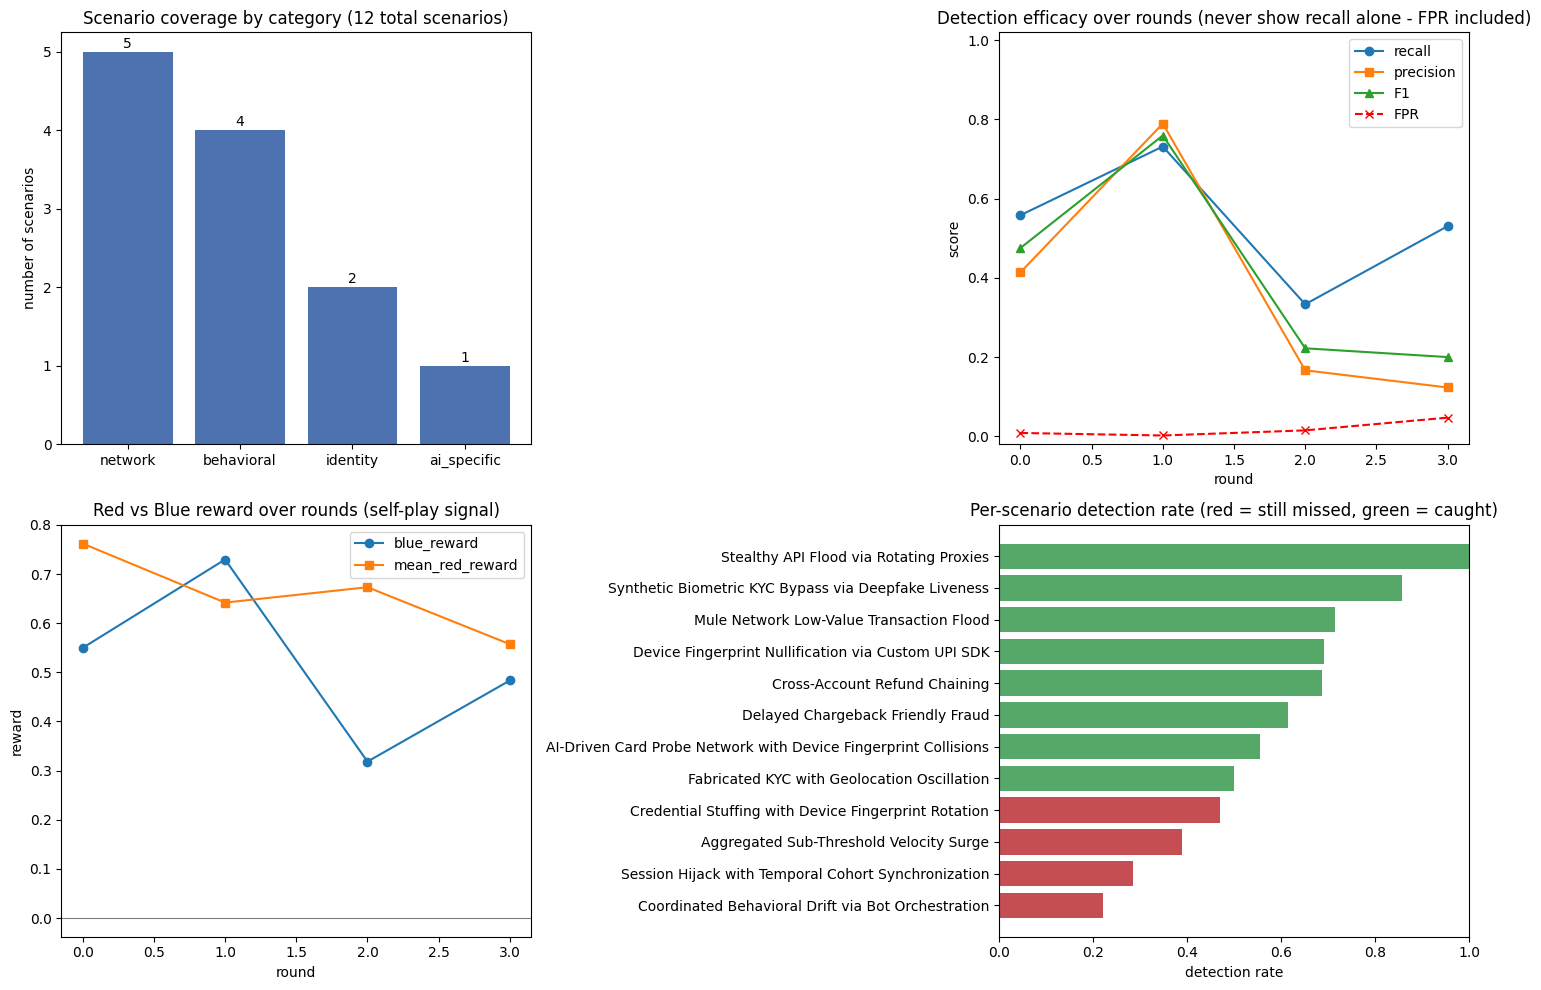


=== Coverage matrix table ===
                                                  scenario_name        f3_tactic                                                      f3_technique manipulation_type                                novelty_tag  detection_rate  round_added
                    Fabricated KYC with Geolocation Oscillation      Positioning                                       Synthetic Identity Creation          identity synthetic_identity_geolocation_oscillation        0.500000            0
           Credential Stuffing with Device Fingerprint Rotation Account Takeover                                               Credential stuffing           network   credential_stuffing_fingerprint_rotation        0.470588            0
                                  Cross-Account Refund Chaining     Monetization                                                Refund/Promo Abuse          identity              cross_account_refund_chaining        0.687500            0
           Synthetic 

In [13]:
import shutil
shutil.copy("data/coverage_matrix_backup_12.csv", "data/coverage_matrix.csv")
shutil.copy("data/dashboard_log_backup_12.csv", "data/dashboard_log.csv")

from dashboard.build_dashboard import build_dashboard
build_dashboard(
    coverage_path="data/coverage_matrix.csv",
    dashboard_log_path="data/dashboard_log.csv",
    save_path="data/final_dashboard.png",
)


In [14]:
import pandas as pd

log = pd.read_csv("data/dashboard_log.csv")
cov = pd.read_csv("data/coverage_matrix.csv")

print("="*60)
print("AGGREGATE METRICS ACROSS ALL ROUNDS")
print("="*60)
print(f"Rounds run:            {log['round'].nunique()}")
print(f"Total transactions:    {log['n_total_txns'].sum():,}")
print(f"Total fraud txns:      {log['n_fraud_txns'].sum():,}")
print()
print(f"Avg ensemble AUC:      {log['ensemble_auc'].mean():.3f}")
print(f"Avg precision:         {log['ensemble_precision'].mean():.3f}")
print(f"Avg recall:            {log['ensemble_recall'].mean():.3f}")
print(f"Avg F1:                {log['ensemble_f1'].mean():.3f}")
print(f"Avg FPR:               {log['blue_fpr'].mean():.4f}")
print()
print(f"Avg blue_reward:       {log['blue_reward'].mean():.3f}")
print(f"Avg red_reward:        {log['mean_red_reward'].mean():.3f}")
print(f"Best round (by F1):    round {log.loc[log['ensemble_f1'].idxmax(), 'round']} "
      f"(F1={log['ensemble_f1'].max():.3f})")
print(f"Worst round (by F1):   round {log.loc[log['ensemble_f1'].idxmin(), 'round']} "
      f"(F1={log['ensemble_f1'].min():.3f})")

print("\n" + "="*60)
print("COVERAGE MATRIX SUMMARY")
print("="*60)
scored = cov[cov["detection_rate"].notna()]
print(f"Total scenarios:        {len(cov)}")
print(f"Scenarios with a score: {len(scored)}")
print(f"Avg detection rate:     {scored['detection_rate'].mean():.3f}")
print(f"Median detection rate:  {scored['detection_rate'].median():.3f}")
print(f"Scenarios at 100%:      {(scored['detection_rate'] == 1.0).sum()}")
print(f"Scenarios at 0%:        {(scored['detection_rate'] == 0.0).sum()}")
print(f"\nBy category:\n{cov['manipulation_type'].value_counts().to_string()}")
print(f"\nMissed at least once:  {(cov['times_missed'] >= 1).sum()} scenarios "
      f"(your before/after improvement story)")

print("\n" + "="*60)
print("TOP / BOTTOM 5 SCENARIOS BY DETECTION RATE")
print("="*60)
print("\nBest detected:")
print(scored.nlargest(5, "detection_rate")[["scenario_name", "detection_rate", "round_added"]].to_string(index=False))
print("\nWorst detected:")
print(scored.nsmallest(5, "detection_rate")[["scenario_name", "detection_rate", "round_added"]].to_string(index=False))

AGGREGATE METRICS ACROSS ALL ROUNDS
Rounds run:            4
Total transactions:    16,024
Total fraud txns:      169

Avg ensemble AUC:      0.911
Avg precision:         0.373
Avg recall:            0.538
Avg F1:                0.414
Avg FPR:               0.0181

Avg blue_reward:       0.520
Avg red_reward:        0.659
Best round (by F1):    round 1 (F1=0.759)
Worst round (by F1):   round 3 (F1=0.200)

COVERAGE MATRIX SUMMARY
Total scenarios:        12
Scenarios with a score: 12
Avg detection rate:     0.582
Median detection rate:  0.585
Scenarios at 100%:      1
Scenarios at 0%:        0

By category:
manipulation_type
network        5
behavioral     4
identity       2
ai_specific    1

Missed at least once:  4 scenarios (your before/after improvement story)

TOP / BOTTOM 5 SCENARIOS BY DETECTION RATE

Best detected:
                                       scenario_name  detection_rate  round_added
             Stealthy API Flood via Rotating Proxies        1.000000            2
Syn